In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

In [2]:
# LOAD FILE
df_clean = pd.read_csv('../data/mta_2021_clean.csv')

In [3]:
# DATAFRAME INFO
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23116991 entries, 0 to 23116990
Data columns (total 16 columns):
 #   Column               Dtype  
---  ------               -----  
 0   transit_timestamp    object 
 1   station_complex      object 
 2   borough              object 
 3   payment_method       object 
 4   fare_class_category  object 
 5   ridership            float64
 6   transfers            float64
 7   latitude             float64
 8   longitude            float64
 9   year                 int64  
 10  month                int64  
 11  month_name           object 
 12  day                  int64  
 13  hour                 int64  
 14  day_of_week          object 
 15  date                 object 
dtypes: float64(4), int64(4), object(8)
memory usage: 2.8+ GB


In [4]:
# UNIQUE MONTHS
df_clean['month_name'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [5]:
# UNIQUE BOROUGHS
df_clean['borough'].unique()

array(['Queens', 'Manhattan', 'Bronx', 'Brooklyn'], dtype=object)

In [6]:
# UNIQUE PAYMENT_METHOD
df_clean['payment_method'].unique()

array(['omny', 'metrocard'], dtype=object)

In [7]:
# UNIQUE FARE_CLASS_CATEGORY
df_clean['fare_class_category'].unique()

array(['OMNY - Full Fare', 'Metrocard - Full Fare',
       'Metrocard - Unlimited 7-Day', 'Metrocard - Other',
       'Metrocard - Unlimited 30-Day', 'Metrocard - Fair Fare',
       'Metrocard - Seniors & Disability', 'Metrocard - Students',
       'OMNY - Seniors & Disability', 'OMNY - Other'], dtype=object)

In [8]:
# TOTAL RIDERSHIP
print('--- Total Ridership ---')
total_ridership = df_clean['ridership'].sum()
print(f"Total Ridership: {total_ridership:,.0f}")

# TOTAL TRANSFERS
print()
print('--- Total Transfers ---')
total_transfers = df_clean['transfers'].sum()
print(f"Total Transfers: {total_transfers:,.0f}")

# TOTAL # UNIQUE STATIONS
print()
print('--- Total Stations ---')
total_stations  = df_clean['station_complex'].nunique()
print(f"Total Stations: {total_stations:,.0f}")

# TOTAL # OF OMNY RIDERSHIP
print()
print('--- Total OMNY Ridership ---')
omny_ridership  = df_clean[df_clean['payment_method'] == 'omny']['ridership'].sum()
print(f"OMNY Ridership: {omny_ridership:,.0f}")

# TOTAL # OF METRO RIDERSHIP
print()
print('--- Total MetroCard Ridership ---')
metro_ridership = df_clean[df_clean['payment_method'] == 'metrocard']['ridership'].sum()
print(f"MetroCard Ridership: {metro_ridership:,.0f}")

# % OMNY/METRO RIDERSHIP
print()
print('--- OMNY/MetroCard Breakdown ---')
omny_pct  = omny_ridership / total_ridership * 100
metro_pct = metro_ridership / total_ridership * 100
print(f"OMNY % {omny_pct:,.0f}")
print(f"MetroCard %: {metro_pct:,.0f}")

--- Total Ridership ---
Total Ridership: 761,103,933

--- Total Transfers ---
Total Transfers: 34,452,964

--- Total Stations ---
Total Stations: 423

--- Total OMNY Ridership ---
OMNY Ridership: 160,613,639

--- Total MetroCard Ridership ---
MetroCard Ridership: 600,490,294

--- OMNY/MetroCard Breakdown ---
OMNY % 21
MetroCard %: 79


In [9]:
# TOTAL RIDERSHIP
print('--- Total Ridership ---')
total_ridership = df_clean['ridership'].sum()
print(total_ridership)

--- Total Ridership ---
761103933.0


In [10]:
# BY BOROUGH
print('--- Ridership by Borough ---')
borough = (
    df_clean.groupby('borough')['ridership']
    .sum()
    .sort_values(ascending=False)
)
print(borough)

--- Ridership by Borough ---
borough
Manhattan    380976157.0
Brooklyn     183571783.0
Queens       123647008.0
Bronx         72908985.0
Name: ridership, dtype: float64


In [11]:
# BY MONTH
print('--- Ridership by Month ---')
monthly = (
    df_clean.groupby(['month', 'month_name'])['ridership']
    .sum()
    .reset_index()
    .sort_values('month')
)
print(monthly)

--- Ridership by Month ---
    month month_name   ridership
0       1    January  41295552.0
1       2   February  39333255.0
2       3      March  50945988.0
3       4      April  53365971.0
4       5        May  58521157.0
5       6       June  65532980.0
6       7       July  66992366.0
7       8     August  66459472.0
8       9  September  73961517.0
9      10    October  83553219.0
10     11   November  82447923.0
11     12   December  78694533.0


In [12]:
# BY WEEK
print('--- Ridership by Day of Week ---')
daily = (
    df_clean.groupby('day_of_week')['ridership']
    .sum()
    .reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
)
print(daily)

--- Ridership by Day of Week ---
day_of_week
Sunday        64945555.0
Monday       113216438.0
Tuesday      123402318.0
Wednesday    126627380.0
Thursday     123565987.0
Friday       125334530.0
Saturday      84011725.0
Name: ridership, dtype: float64


In [13]:
# BY HOUR
print('--- Ridership by Hour (5AM - 12AM) ---')
hourly_filtered = (
    df_clean.groupby('hour')['ridership']
    .sum()
    .reindex(range(5, 24))  # 5AM to 11PM (23:00)
    .reset_index()
)
print(hourly_filtered)

--- Ridership by Hour (5AM - 12AM) ---
    hour   ridership
0      5  15805356.0
1      6  32699835.0
2      7  51819451.0
3      8  54933568.0
4      9  38656955.0
5     10  32922343.0
6     11  32957843.0
7     12  36349292.0
8     13  41347314.0
9     14  49729352.0
10    15  59254036.0
11    16  63860195.0
12    17  66750324.0
13    18  52840076.0
14    19  37063858.0
15    20  26857648.0
16    21  20795555.0
17    22  18078288.0
18    23  12863534.0


In [14]:
# TOTAL RIDERSHIP
print('--- Total Ridership ---')
total_ridership = df_clean['ridership'].sum()
print(f"Total Ridership: {total_ridership:,.0f}")

# TOTAL TRANSFERS
print()
print('--- Total Transfers ---')
total_transfers = df_clean['transfers'].sum()
print(f"Total Transfers: {total_transfers:,.0f}")

# TOTAL # UNIQUE STATIONS
print()
print('--- Total Stations ---')
total_stations  = df_clean['station_complex'].nunique()
print(f"Total Stations: {total_stations:,.0f}")

# TOTAL # OF OMNY RIDERSHIP
print()
print('--- Total OMNY Ridership ---')
omny_ridership  = df_clean[df_clean['payment_method'] == 'omny']['ridership'].sum()
print(f"OMNY Ridership: {omny_ridership:,.0f}")

# TOTAL # OF METRO RIDERSHIP
print()
print('--- Total MetroCard Ridership ---')
metro_ridership = df_clean[df_clean['payment_method'] == 'metrocard']['ridership'].sum()
print(f"MetroCard Ridership: {metro_ridership:,.0f}")

# % OMNY/METRO RIDERSHIP
print()
print('--- OMNY/MetroCard Breakdown ---')
omny_pct  = omny_ridership / total_ridership * 100
metro_pct = metro_ridership / total_ridership * 100
print(f"OMNY % {omny_pct:,.0f}")
print(f"MetroCard %: {metro_pct:,.0f}")

--- Total Ridership ---
Total Ridership: 761,103,933

--- Total Transfers ---
Total Transfers: 34,452,964

--- Total Stations ---
Total Stations: 423

--- Total OMNY Ridership ---
OMNY Ridership: 160,613,639

--- Total MetroCard Ridership ---
MetroCard Ridership: 600,490,294

--- OMNY/MetroCard Breakdown ---
OMNY % 21
MetroCard %: 79


In [15]:
# BUSIEST STATION
print('--- Busiest Station ---')
busiest_station = df_clean.groupby('station_complex')['ridership'].sum().idxmax()
busiest_station_total = df_clean.groupby('station_complex')['ridership'].sum().max()
print(f"{busiest_station}: {busiest_station_total:,.0f}")

# BUSIEST MONTH
print()
print('--- Busiest Month ---')
busiest_month = df_clean.groupby('month_name')['ridership'].sum().idxmax()
busiest_month_total = df_clean.groupby('month_name')['ridership'].sum().max()
print(f"{busiest_month}: {busiest_month_total:,.0f}")

# BUSIEST DAY OF WEEK
print()
print('--- Busiest Day of Week ---')
busiest_day = df_clean.groupby('day_of_week')['ridership'].sum().idxmax()
busiest_day_total = df_clean.groupby('day_of_week')['ridership'].sum().max()
print(f"{busiest_day}: {busiest_day_total:,.0f}")

# BUSIEST HOUR
print()
print('--- Busiest Hour ---')
busiest_hour = df_clean.groupby('hour')['ridership'].sum().idxmax()
busiest_hour_total = df_clean.groupby('hour')['ridership'].sum().max()
print(f"{busiest_hour}: {busiest_hour_total:,.0f}")

--- Busiest Station ---
Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E): 23,386,076

--- Busiest Month ---
October: 83,553,219

--- Busiest Day of Week ---
Wednesday: 126,627,380

--- Busiest Hour ---
17: 66,750,324


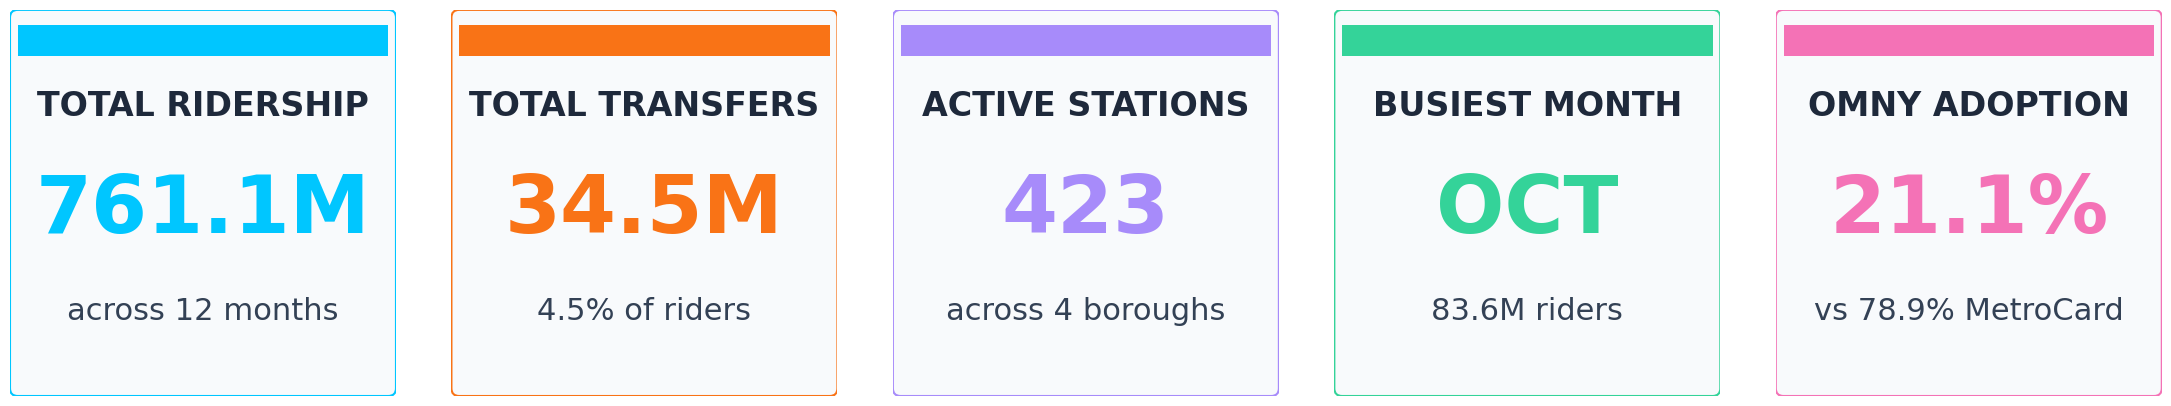

Saved: ../output/kpi_cards.png


<Figure size 640x480 with 0 Axes>

In [16]:
kpis = [
    ('Total Ridership',  '761.1M',  'across 12 months'),
    ('Total Transfers',  '34.5M',   '4.5% of riders'),
    ('Active Stations',  '423',     'across 4 boroughs'),
    ('Busiest Month',    'OCT',     '83.6M riders'),
    ('OMNY Adoption',    '21.1%',   'vs 78.9% MetroCard'),
]


# COLORS
colors = ['#00c6ff', '#f97316', '#a78bfa', '#34d399', '#f472b6']

# FIG
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.patch.set_facecolor('white')

for ax, (label, value, sub), color in zip(axes, kpis, colors):
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # CARD BORDER
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02',
        linewidth=1.5,
        edgecolor=color,
        facecolor='#f8fafc'
    ))

    # ACCENT BAR
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.88), 0.96, 0.08,
        boxstyle='square,pad=0',
        linewidth=0,
        facecolor=color
    ))

    # LABEL
    ax.text(0.5, 0.75, label.upper(),
            ha='center', va='center',
            fontsize=24, color='#1e293b',
            fontweight='bold',
            transform=ax.transAxes)

    # VALUE
    ax.text(0.5, 0.48, value,
            ha='center', va='center',
            fontsize=58, color=color,
            fontweight='bold',
            transform=ax.transAxes)

    # TEXT
    ax.text(0.5, 0.22, sub,
            ha='center', va='center',
            fontsize=22, color='#334155',
            fontweight='normal',
            transform=ax.transAxes)

plt.tight_layout(pad=0.5)
plt.show()

plt.savefig('../output/kpi_cards.png', dpi=150, bbox_inches='tight', facecolor='white')
print('Saved: ../output/kpi_cards.png')

In [17]:
# TOP 10 BUSIEST STATIONS
print('--- Top 10 Busiest Stations ---')
top_stations = (
    df_clean.groupby(['station_complex', 'borough'])['ridership']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_stations)

--- Top 10 Busiest Stations ---
                                     station_complex    borough   ridership
0   Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)  Manhattan  23386076.0
1                                 34 St-Penn Station  Manhattan  18989222.0
2                  34 St-Herald Sq (B,D,F,M,N,Q,R,W)  Manhattan  15001842.0
3                    Grand Central-42 St (S,4,5,6,7)  Manhattan  14098854.0
4                   14 St-Union Sq (L,N,Q,R,W,4,5,6)  Manhattan  13182449.0
5                        Fulton St (A,C,J,Z,2,3,4,5)  Manhattan   9708458.0
6  74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...     Queens   9420594.0
7                               Flushing-Main St (7)     Queens   9349536.0
8                  59 St-Columbus Circle (A,B,C,D,1)  Manhattan   9323098.0
9                 Lexington Av (N,R,W)/59 St (4,5,6)  Manhattan   7381046.0


In [18]:
# TOP 10 BUSIEST STATIONS (NAMES SIMPLIFIED)
print('--- Top 10 Busiest Stations ---')
top_stations['station_name'] = (
    top_stations['station_complex']
    .str.replace(r'\s*\(.*?\)', '', regex=True)
    .str.strip()
)

print(top_stations[['station_name', 'borough', 'ridership']])

--- Top 10 Busiest Stations ---
                           station_name    borough   ridership
0                  Times Sq-42 St/42 St  Manhattan  23386076.0
1                    34 St-Penn Station  Manhattan  18989222.0
2                       34 St-Herald Sq  Manhattan  15001842.0
3                   Grand Central-42 St  Manhattan  14098854.0
4                        14 St-Union Sq  Manhattan  13182449.0
5                             Fulton St  Manhattan   9708458.0
6  74-Broadway/Jackson Hts-Roosevelt Av     Queens   9420594.0
7                      Flushing-Main St     Queens   9349536.0
8                 59 St-Columbus Circle  Manhattan   9323098.0
9                    Lexington Av/59 St  Manhattan   7381046.0


In [19]:
# RIDERSHIP BY BOROUGH BASELINE
borough = (
    df_clean.groupby('borough')['ridership']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print('--- Ridership by Borough ---')
print(borough)

--- Ridership by Borough ---
     borough    ridership
0  Manhattan  380976157.0
1   Brooklyn  183571783.0
2     Queens  123647008.0
3      Bronx   72908985.0


In [20]:
print('--- Ridership by Borough (Millions) ---')
borough['ridership_m'] = borough['ridership'] / 1e6
print(borough)

--- Ridership by Borough (Millions) ---
     borough    ridership  ridership_m
0  Manhattan  380976157.0   380.976157
1   Brooklyn  183571783.0   183.571783
2     Queens  123647008.0   123.647008
3      Bronx   72908985.0    72.908985


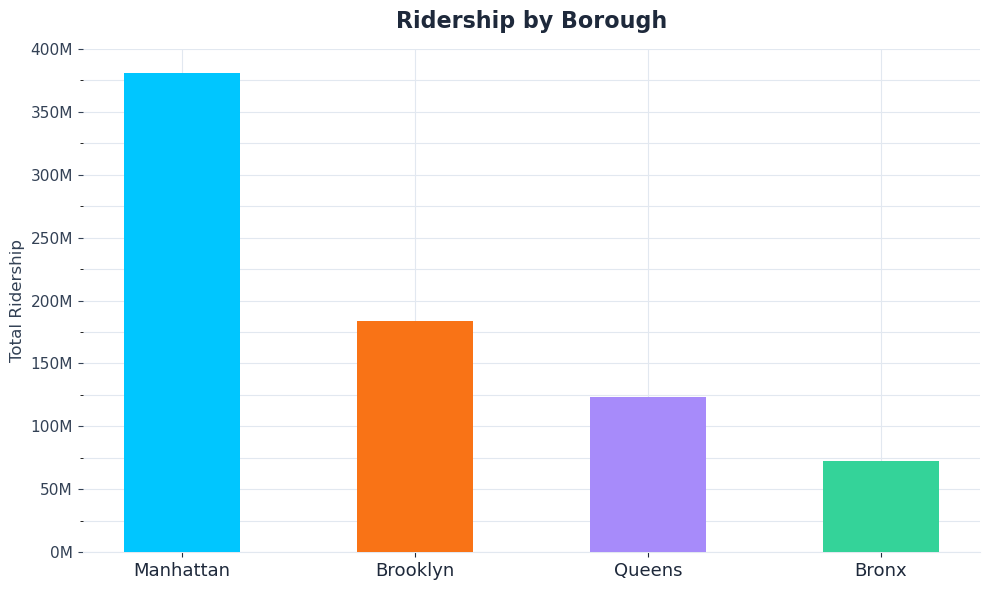

Saved: ../output/ridership_by_borough.png


<Figure size 640x480 with 0 Axes>

In [21]:
# FIG
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# BARS
ax.bar(
    borough['borough'],
    borough['ridership_m'],
    color=colors,
    width=0.5,
    zorder=3
)

# GRIDLINES
ax.set_yticks(range(0, 425, 25))
ax.set_yticks(range(0, 425, 50), minor=False)
ax.set_yticks(range(0, 425, 25), minor=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.grid(True, which='both', color='#e2e8f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# AXIS
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e2e8f0')
ax.xaxis.set_tick_params(labelsize=13, colors='#1e293b')
ax.yaxis.set_tick_params(labelsize=11, colors='#334155')

# TITLE/LABELS
ax.set_title('Ridership by Borough', fontsize=16, fontweight='bold',
             color='#1e293b', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Ridership', fontsize=12, color='#334155')

plt.tight_layout()
plt.show()

plt.savefig('../output/ridership_by_borough.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/ridership_by_borough.png')

In [22]:
# RIDERSHIP % BY BOROUGH
total = borough['ridership'].sum()
borough['pct'] = borough['ridership'] / total * 100

print('--- Ridership % by Borough ---')
print(borough)

--- Ridership % by Borough ---
     borough    ridership  ridership_m        pct
0  Manhattan  380976157.0   380.976157  50.055734
1   Brooklyn  183571783.0   183.571783  24.119148
2     Queens  123647008.0   123.647008  16.245746
3      Bronx   72908985.0    72.908985   9.579373


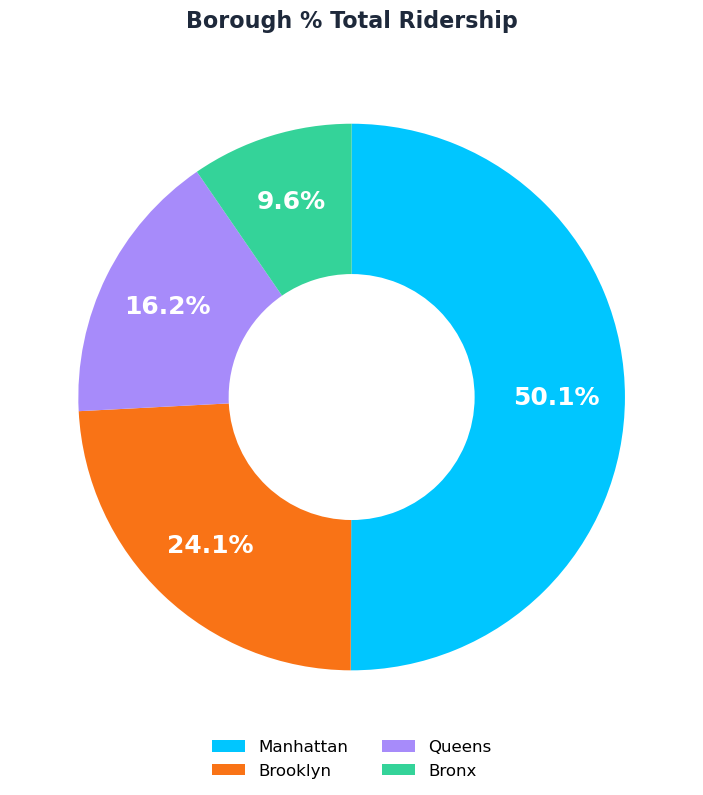

Saved: ../output/borough_share_donut.png


<Figure size 640x480 with 0 Axes>

In [23]:
# COLORS
colors = ['#00c6ff', '#f97316', '#a78bfa', '#34d399']

# FIG
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

wedges, texts = ax.pie(
    borough['ridership'],
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.55),
)

# PERCENTAGE
for i, (wedge, row) in enumerate(zip(wedges, borough.itertuples())):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.75 * np.cos(np.radians(angle))
    y = 0.75 * np.sin(np.radians(angle))
    ax.text(x, y,
            f'{row.pct:.1f}%',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white')

# TITLE
ax.set_title('Borough % Total Ridership', fontsize=16,
             fontweight='bold', color='#1e293b', pad=20)

# LEGEND
ax.legend(
    wedges,
    [row.borough for row in borough.itertuples()],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()

plt.savefig('../output/borough_share_donut.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/borough_share_donut.png')

In [24]:
# RIDERSHIP BY MONTH
monthly = (
    df_clean.groupby(['month', 'month_name'])['ridership']
    .sum()
    .reset_index()
    .sort_values('month')
)

monthly['ridership_m'] = monthly['ridership'] / 1e6

print('--- Ridership Month ---')
print(monthly)

--- Ridership Month ---
    month month_name   ridership  ridership_m
0       1    January  41295552.0    41.295552
1       2   February  39333255.0    39.333255
2       3      March  50945988.0    50.945988
3       4      April  53365971.0    53.365971
4       5        May  58521157.0    58.521157
5       6       June  65532980.0    65.532980
6       7       July  66992366.0    66.992366
7       8     August  66459472.0    66.459472
8       9  September  73961517.0    73.961517
9      10    October  83553219.0    83.553219
10     11   November  82447923.0    82.447923
11     12   December  78694533.0    78.694533


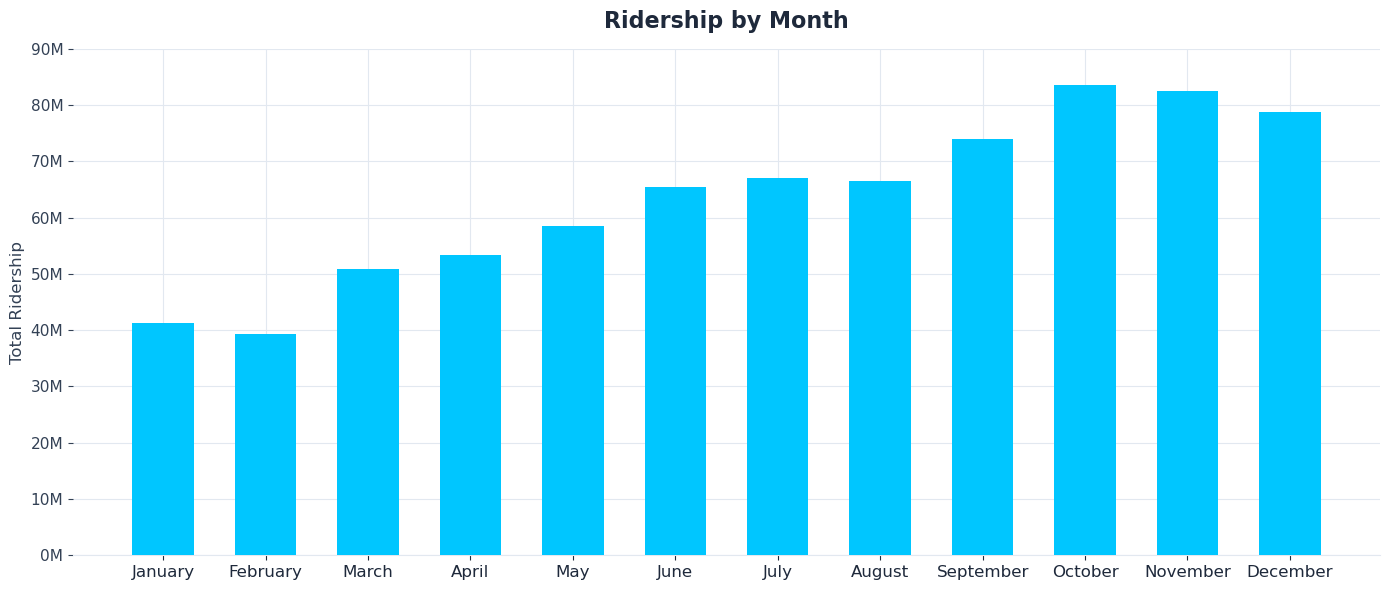

Saved: ../output/ridership_by_month.png


<Figure size 640x480 with 0 Axes>

In [25]:
# FIG
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# BAR
ax.bar(
    monthly['month_name'],
    monthly['ridership_m'],
    color='#00c6ff',
    width=0.6,
    zorder=3
)

# GRIDLINES
ax.set_yticks(range(0, 100, 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
ax.grid(True, which='major', color='#e2e8f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# AXIS
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e2e8f0')
ax.xaxis.set_tick_params(labelsize=12, colors='#1e293b')
ax.yaxis.set_tick_params(labelsize=11, colors='#334155')

# TITLE/LABEL
ax.set_title('Ridership by Month', fontsize=16, fontweight='bold',
             color='#1e293b', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Ridership', fontsize=12, color='#334155')

plt.tight_layout()
plt.show()

plt.savefig('../output/ridership_by_month.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/ridership_by_month.png')

In [26]:
# RIDERSHIP DAILY
daily = (
    df_clean.groupby('day_of_week')['ridership']
    .sum()
    .reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
    .reset_index()
)

daily['ridership_m'] = daily['ridership'] / 1e6

print('--- Ridership Daily ---')
print(daily)

--- Ridership Daily ---
  day_of_week    ridership  ridership_m
0      Sunday   64945555.0    64.945555
1      Monday  113216438.0   113.216438
2     Tuesday  123402318.0   123.402318
3   Wednesday  126627380.0   126.627380
4    Thursday  123565987.0   123.565987
5      Friday  125334530.0   125.334530
6    Saturday   84011725.0    84.011725


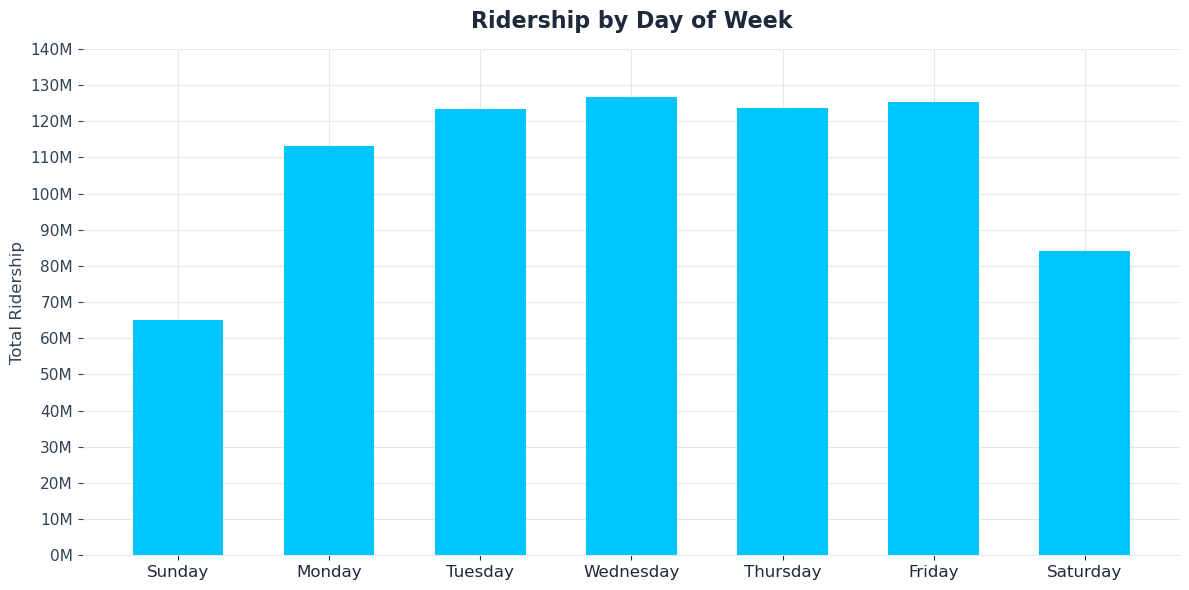

Saved: ../output/ridership_by_day.png


<Figure size 640x480 with 0 Axes>

In [27]:
# FIG
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(
    daily['day_of_week'],
    daily['ridership_m'],
    color='#00c6ff',
    width=0.6,
    zorder=3
)

# GRIDLINES
ax.set_yticks(range(0, 150, 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
ax.grid(True, which='major', color='#e2e8f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# AXIS
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e2e8f0')
ax.xaxis.set_tick_params(labelsize=12, colors='#1e293b')
ax.yaxis.set_tick_params(labelsize=11, colors='#334155')

# TITLE/LABELS
ax.set_title('Ridership by Day of Week', fontsize=16, fontweight='bold',
             color='#1e293b', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Ridership', fontsize=12, color='#334155')

plt.tight_layout()
plt.show()

plt.savefig('../output/ridership_by_day.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/ridership_by_day.png')

In [28]:
# RIDERSHIP HOURLY
hourly = (
    df_clean.groupby('hour')['ridership']
    .sum()
    .reindex(range(5, 24))
    .reset_index()
)

# convert to millions
hourly['ridership_m'] = hourly['ridership'] / 1e6

print('--- Ridership Hourly ---')
print(hourly)

--- Ridership Hourly ---
    hour   ridership  ridership_m
0      5  15805356.0    15.805356
1      6  32699835.0    32.699835
2      7  51819451.0    51.819451
3      8  54933568.0    54.933568
4      9  38656955.0    38.656955
5     10  32922343.0    32.922343
6     11  32957843.0    32.957843
7     12  36349292.0    36.349292
8     13  41347314.0    41.347314
9     14  49729352.0    49.729352
10    15  59254036.0    59.254036
11    16  63860195.0    63.860195
12    17  66750324.0    66.750324
13    18  52840076.0    52.840076
14    19  37063858.0    37.063858
15    20  26857648.0    26.857648
16    21  20795555.0    20.795555
17    22  18078288.0    18.078288
18    23  12863534.0    12.863534


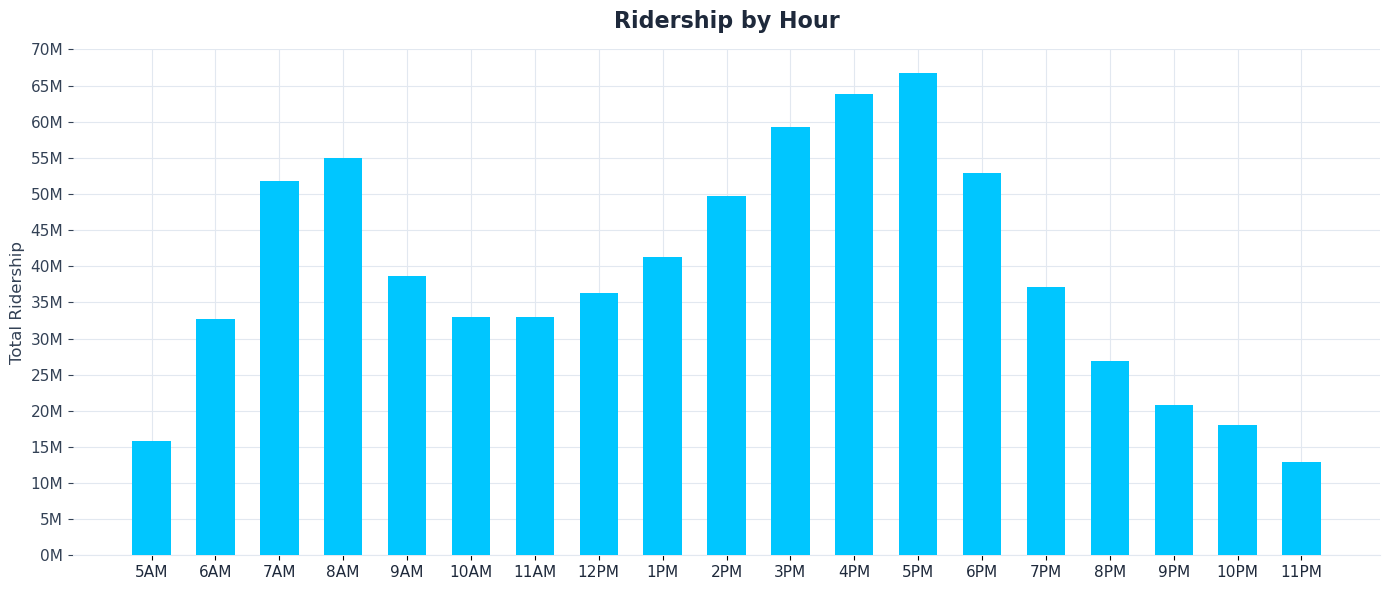

Saved: ../output/ridership_by_hour.png


<Figure size 640x480 with 0 Axes>

In [29]:
# FIG
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(
    hourly['hour'],
    hourly['ridership_m'],
    color='#00c6ff',
    width=0.6,
    zorder=3
)

# LABELS
hour_labels = ['5AM','6AM','7AM','8AM','9AM','10AM','11AM','12PM',
               '1PM','2PM','3PM','4PM','5PM','6PM','7PM','8PM',
               '9PM','10PM','11PM']
ax.set_xticks(range(5, 24))
ax.set_xticklabels(hour_labels, fontsize=11, color='#1e293b')

# GRIDLINES
ax.set_yticks(range(0, 75, 5))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
ax.grid(True, which='major', color='#e2e8f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# AXIS
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e2e8f0')
ax.yaxis.set_tick_params(labelsize=11, colors='#334155')

# TITLE/LABELS
ax.set_title('Ridership by Hour', fontsize=16, fontweight='bold',
             color='#1e293b', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Ridership', fontsize=12, color='#334155')

plt.tight_layout()
plt.show()

plt.savefig('../output/ridership_by_hour.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/ridership_by_hour.png')

In [30]:
# RIDERSHIP BY STATION/BOROUGH
top_stations = (
    df_clean.groupby(['station_complex', 'borough'])['ridership']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# CLEAN STATIION NAMES
top_stations['station_name'] = (
    top_stations['station_complex']
    .str.replace(r'\s*\(.*?\)', '', regex=True)
    .str.strip()
)

top_stations['ridership_m'] = top_stations['ridership'] / 1e6

print('--- Top Stations ---')
print(top_stations)

--- Top Stations ---
                                     station_complex    borough   ridership  \
0   Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)  Manhattan  23386076.0   
1                                 34 St-Penn Station  Manhattan  18989222.0   
2                  34 St-Herald Sq (B,D,F,M,N,Q,R,W)  Manhattan  15001842.0   
3                    Grand Central-42 St (S,4,5,6,7)  Manhattan  14098854.0   
4                   14 St-Union Sq (L,N,Q,R,W,4,5,6)  Manhattan  13182449.0   
5                        Fulton St (A,C,J,Z,2,3,4,5)  Manhattan   9708458.0   
6  74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...     Queens   9420594.0   
7                               Flushing-Main St (7)     Queens   9349536.0   
8                  59 St-Columbus Circle (A,B,C,D,1)  Manhattan   9323098.0   
9                 Lexington Av (N,R,W)/59 St (4,5,6)  Manhattan   7381046.0   

                           station_name  ridership_m  
0                  Times Sq-42 St/42 St    23.386076  

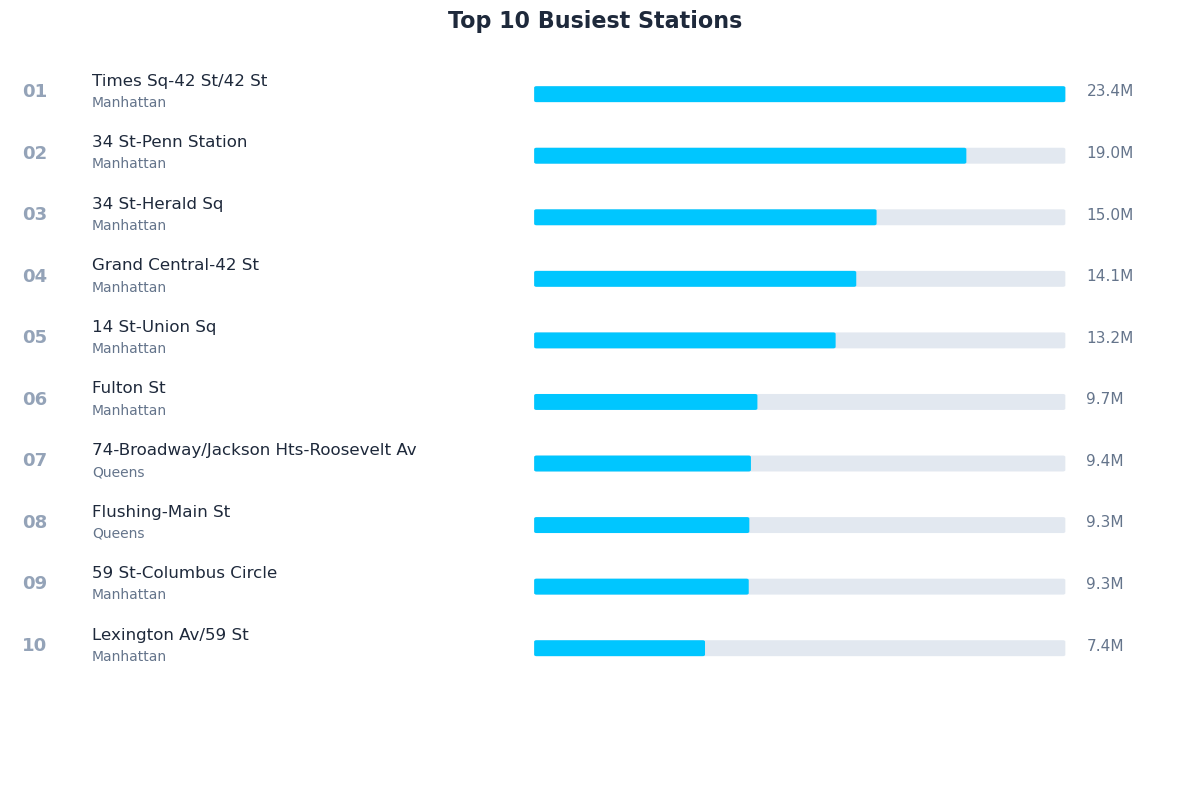

Saved: ../output/top_10_stations.png


<Figure size 640x480 with 0 Axes>

In [31]:
# NORMALIZE BAR WIDTHS
max_ridership = top_stations['ridership_m'].max()
top_stations['bar_width'] = top_stations['ridership_m'] / max_ridership

# COLORS
bar_color = '#00c6ff'
bg_color  = '#e2e8f0'

# FIG
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# STATION ROW
n = len(top_stations)
row_height = 0.085
start_y = 0.95

for i, row in top_stations.iterrows():
    y = start_y - (i * row_height)

    # RANK
    ax.text(0.01, y, f'{i+1:02d}',
            va='center', ha='left',
            fontsize=13, fontweight='bold',
            color='#94a3b8')

    # STATION NAME
    ax.text(0.07, y + 0.015, row['station_name'],
            va='center', ha='left',
            fontsize=12, fontweight='500',
            color='#1e293b')

    # BOROUGH
    ax.text(0.07, y - 0.015, row['borough'],
            va='center', ha='left',
            fontsize=10,
            color='#64748b')

    # BACKGROUND BAR
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.45, y - 0.012), 0.45, 0.018,
        boxstyle='round,pad=0.002',
        facecolor=bg_color,
        edgecolor='none'
    ))

    # FOREGROUND BAR
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.45, y - 0.012), 0.45 * row['bar_width'], 0.018,
        boxstyle='round,pad=0.002',
        facecolor=bar_color,
        edgecolor='none'
    ))

    # RIDERSHIP VALUE
    ax.text(0.92, y, f"{row['ridership_m']:.1f}M",
            va='center', ha='left',
            fontsize=11, color='#64748b')

# TITLE
ax.set_title('Top 10 Busiest Stations', fontsize=16,
             fontweight='bold', color='#1e293b', pad=20)

plt.tight_layout()
plt.show()

plt.savefig('../output/top_10_stations.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/top_10_stations.png')

In [32]:
# FARE CLASS BREAKDOWN
fare = (
    df_clean.groupby('fare_class_category')['ridership']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fare['ridership_m'] = fare['ridership'] / 1e6

print('--- Fare Class Breakdown ---')
print(fare)

--- Fare Class Breakdown ---
                fare_class_category    ridership  ridership_m
0             Metrocard - Full Fare  274126466.0   274.126466
1                  OMNY - Full Fare  160610480.0   160.610480
2       Metrocard - Unlimited 7-Day  113222854.0   113.222854
3      Metrocard - Unlimited 30-Day   99178854.0    99.178854
4                 Metrocard - Other   38672446.0    38.672446
5  Metrocard - Seniors & Disability   28498343.0    28.498343
6             Metrocard - Fair Fare   24069091.0    24.069091
7              Metrocard - Students   22722240.0    22.722240
8       OMNY - Seniors & Disability       1999.0     0.001999
9                      OMNY - Other       1160.0     0.001160


In [33]:
# FARE LABELS
fare['label'] = fare['fare_class_category'].replace({
    'Metrocard - Full Fare':  'MC',
    'OMNY - Full Fare':       'OMNY',
    'Metrocard - Other':      'MC Other*',
})

top_8_fares = fare.head(8)
print('--- Fare Class Breakdown ---')
print(top_8_fares)

--- Fare Class Breakdown ---
                fare_class_category    ridership  ridership_m  \
0             Metrocard - Full Fare  274126466.0   274.126466   
1                  OMNY - Full Fare  160610480.0   160.610480   
2       Metrocard - Unlimited 7-Day  113222854.0   113.222854   
3      Metrocard - Unlimited 30-Day   99178854.0    99.178854   
4                 Metrocard - Other   38672446.0    38.672446   
5  Metrocard - Seniors & Disability   28498343.0    28.498343   
6             Metrocard - Fair Fare   24069091.0    24.069091   
7              Metrocard - Students   22722240.0    22.722240   

                              label  
0                                MC  
1                              OMNY  
2       Metrocard - Unlimited 7-Day  
3      Metrocard - Unlimited 30-Day  
4                         MC Other*  
5  Metrocard - Seniors & Disability  
6             Metrocard - Fair Fare  
7              Metrocard - Students  


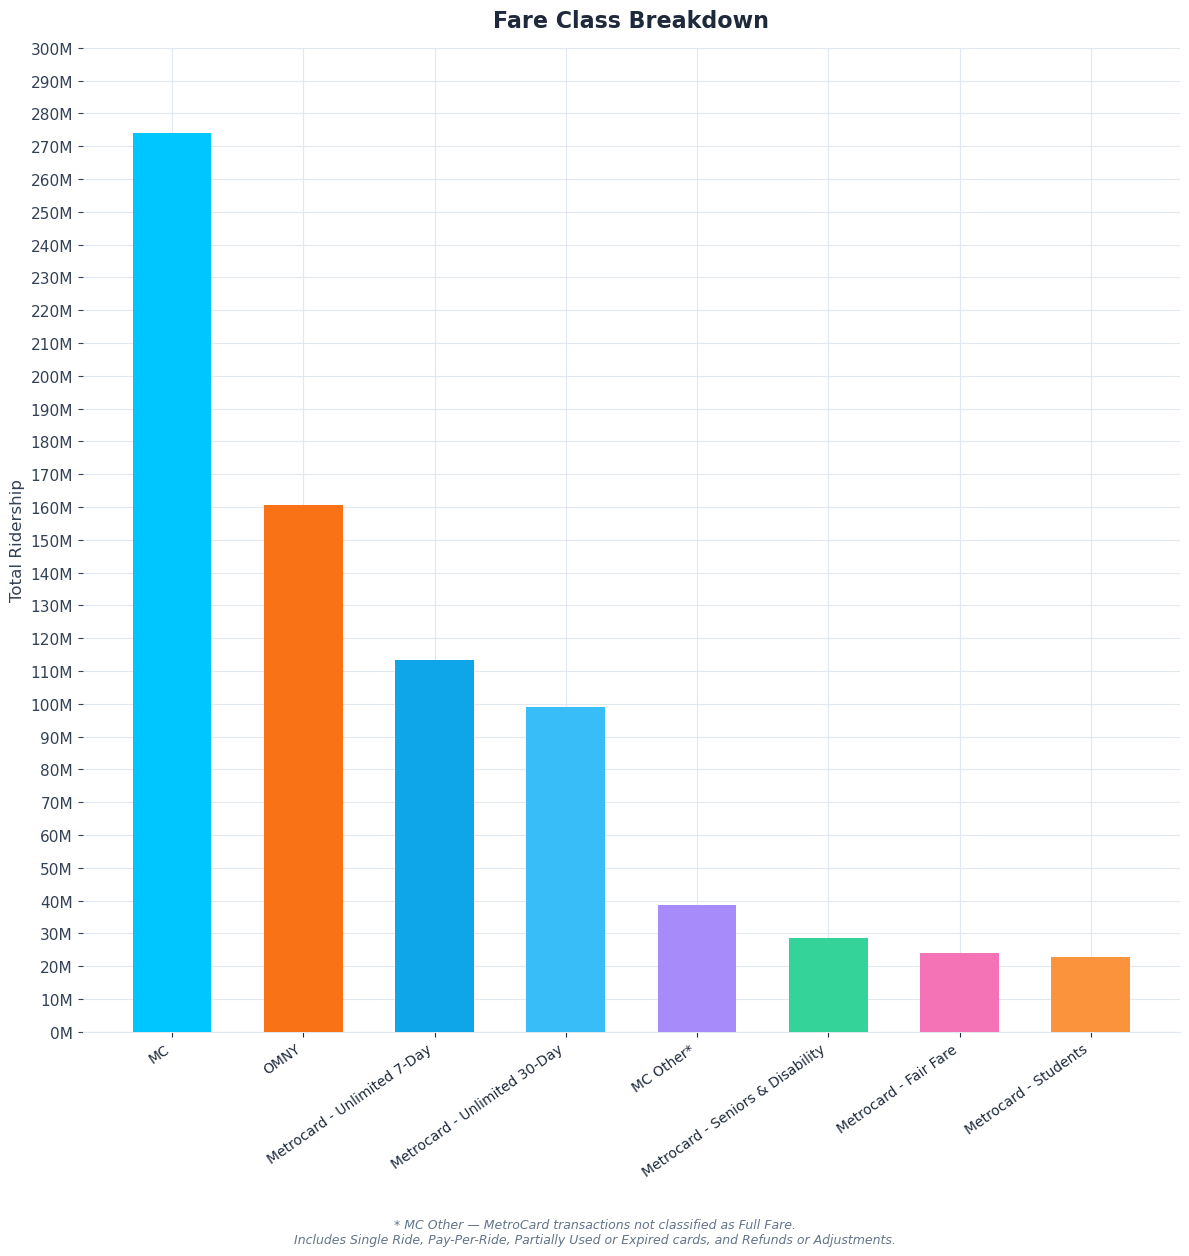

Saved: ../output/fare_class_breakdown.png


<Figure size 640x480 with 0 Axes>

In [34]:
# COLORS
colors = ['#00c6ff', '#f97316', '#0ea5e9', '#38bdf8',
          '#a78bfa', '#34d399', '#f472b6', '#fb923c']

# FIG
fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# BAR
ax.bar(
    top_8_fares['label'],
    top_8_fares['ridership_m'],
    color=colors[:len(top_8_fares)],
    width=0.6,
    zorder=3
)

# GRIDLINES
ax.set_yticks(range(0, 310, 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}M'))
ax.grid(True, which='major', color='#e2e8f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# AXIS
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e2e8f0')
ax.xaxis.set_tick_params(labelsize=10, colors='#1e293b')
ax.yaxis.set_tick_params(labelsize=11, colors='#334155')
plt.xticks(rotation=35, ha='right')

# TITLE/LABELS
ax.set_title('Fare Class Breakdown', fontsize=16, fontweight='bold',
             color='#1e293b', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Ridership', fontsize=12, color='#334155')

# FOOTNOTE
fig.text(0.5, -0.02,
         '* MC Other — MetroCard transactions not classified as Full Fare.\n'
         'Includes Single Ride, Pay-Per-Ride, Partially Used or Expired cards, and Refunds or Adjustments.',
         ha='center', va='top',
         fontsize=9, color='#64748b',
         style='italic')

plt.tight_layout()
plt.show()

plt.savefig('../output/fare_class_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/fare_class_breakdown.png')

In [35]:
insights = [
    ('Weekday vs Weekend Gap',
     'Weekday ridership averages ~118M per day vs ~74M on\nweekends — weekdays drive roughly 60% more traffic\nthan weekend days.',
     '#00c6ff'),
    ('Manhattan Dominance',
     'Manhattan accounts for 50.1% of all ridership. All top\n5 busiest stations are in Manhattan, led by Times\nSquare at 23.4M riders.',
     '#f97316'),
    ('Unlimited Pass Usage',
     '7-day and 30-day unlimited passes combined account\nfor 29.5% of all rides — reflecting a strong commuter\nbase relying on flat-rate travel.',
     '#f472b6'),
    ('OMNY Growth',
     'OMNY contactless payments reached 21.1% adoption\nin 2021 — nearly doubling from 11.5% in January as\nthe system expanded citywide.',
     '#a78bfa'),
]

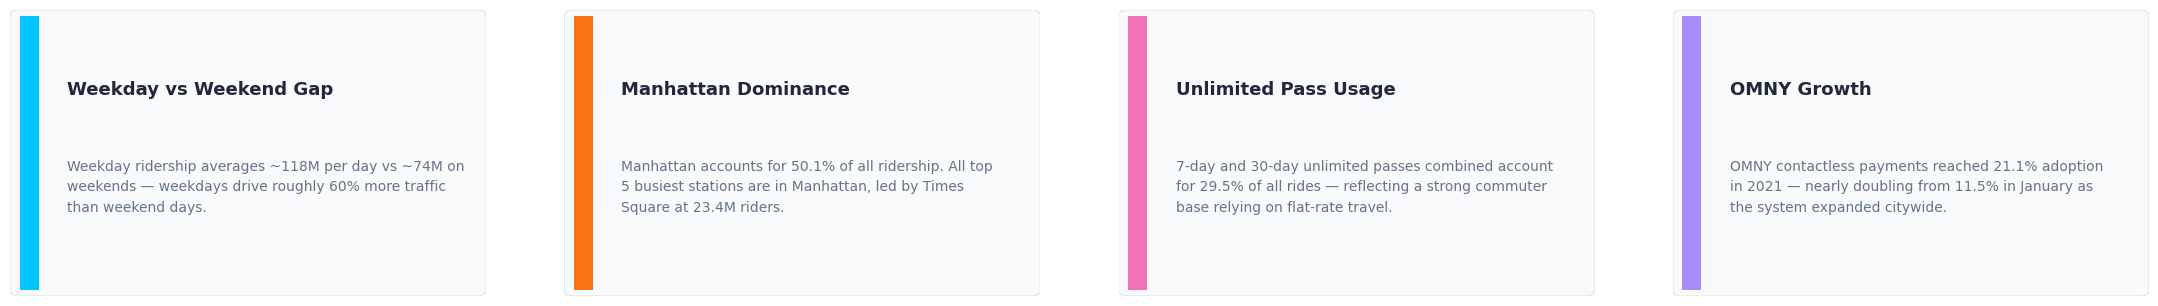

Saved: ../output/key_insights.png


<Figure size 640x480 with 0 Axes>

In [36]:
# FIG
fig, axes = plt.subplots(1, 4, figsize=(22, 3))
fig.patch.set_facecolor('white')

for ax, (title, body, color) in zip(axes, insights):
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # CARD BACKGROUND
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02',
        linewidth=1,
        edgecolor='#e2e8f0',
        facecolor='#f8fafc'
    ))

    # ACCENT BORDER
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.02), 0.04, 0.96,
        boxstyle='square,pad=0',
        linewidth=0,
        facecolor=color
    ))

    # TITLE
    ax.text(0.12, 0.72, title,
            ha='left', va='center',
            fontsize=13, fontweight='bold',
            color='#1e293b',
            transform=ax.transAxes)

    # BODY TEXT
    ax.text(0.12, 0.38, body,
            ha='left', va='center',
            fontsize=10, color='#64748b',
            linespacing=1.6,
            transform=ax.transAxes)

plt.tight_layout(pad=0.5)
plt.show()

plt.savefig('../output/key_insights.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('Saved: ../output/key_insights.png')